# Symbolisches Lösen einer DGL — Universelles Template
**Aufgabe:** Anfangswertproblem für eine lineare DGL 2. Ordnung:
$$\ddot{x}(t) + a\,\dot{x}(t) + b\,x(t) = g(t), \qquad x(0) = x_0,\; \dot{x}(0) = v_0$$

Gesucht:
1. Allgemeine Lösung der **homogenen** DGL
2. Allgemeine Lösung der **inhomogenen** DGL
3. Lösung des **Anfangswertproblems**
4. Skizze der Lösung

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

## 1. DGL definieren — NUR HIER ANPASSEN

In [2]:
t = sp.Symbol('t')
x = sp.Function('x')

# ── Anfangsbedingungen ────────────────────────────────────────────────────────
x0  = 0    # x(0)
v0  = 1    # x'(0)

# ── Rechte Seite g(t) der inhomogenen DGL ────────────────────────────────────
# Beispiel: x'' + 3x' + 2x = 2*sin(t)
g = 2 * sp.sin(t)

# ── DGL aufstellen: x''(t) + a*x'(t) + b*x(t) = g(t) ────────────────────────
ode = sp.Eq(x(t).diff(t, 2) + 3*x(t).diff(t) + 2*x(t), g)

print("DGL:", ode)

DGL: Eq(2*x(t) + 3*Derivative(x(t), t) + Derivative(x(t), (t, 2)), 2*sin(t))


## 2. Allgemeine Lösung der homogenen DGL (g = 0)

In [3]:
ode_hom = sp.Eq(x(t).diff(t, 2) + 3*x(t).diff(t) + 2*x(t), 0)

x_hom = sp.dsolve(ode_hom, x(t))
print("Homogene Lösung:")
sp.pprint(x_hom)

Homogene Lösung:
       ⎛         -t⎞  -t
x(t) = ⎝C₁ + C₂⋅ℯ  ⎠⋅ℯ  


## 3. Allgemeine Lösung der inhomogenen DGL

In [4]:
x_inhom = sp.dsolve(ode, x(t))
print("Inhomogene Lösung (allgemein):")
sp.pprint(x_inhom)

Inhomogene Lösung (allgemein):
           -2⋅t       -t   sin(t)   3⋅cos(t)
x(t) = C₁⋅ℯ     + C₂⋅ℯ   + ────── - ────────
                             5         5    


## 4. Anfangswertproblem — Konstanten C1, C2 bestimmen

In [5]:
C1, C2 = sp.symbols('C1 C2')

# Allgemeine Lösung auslesen
x_allg = x_inhom.rhs

# Gleichungssystem für AB: x(0)=x0, x'(0)=v0
eq1 = sp.Eq(x_allg.subs(t, 0), x0)
eq2 = sp.Eq(x_allg.diff(t).subs(t, 0), v0)

constants = sp.solve([eq1, eq2], [C1, C2])
print("Konstanten:", constants)

# Partikuläre Lösung
x_part = x_allg.subs(constants)
x_part = sp.simplify(x_part)
print("\nLösung des Anfangswertproblems:")
sp.pprint(x_part)

Konstanten: {C1: -7/5, C2: 2}

Lösung des Anfangswertproblems:
                               -2⋅t
sin(t)   3⋅cos(t)      -t   7⋅ℯ    
────── - ──────── + 2⋅ℯ   - ───────
  5         5                  5   


## 5. Skizze der Lösung

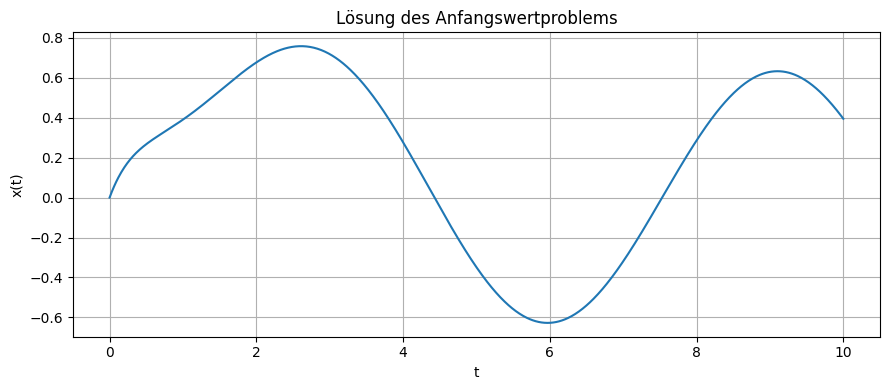

In [6]:
# Zeitbereich anpassen
t_vals = np.linspace(0, 10, 1000)

x_func = sp.lambdify(t, x_part, 'numpy')
x_vals = x_func(t_vals)

plt.figure(figsize=(9, 4))
plt.plot(t_vals, x_vals)
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Lösung des Anfangswertproblems')
plt.grid(True)
plt.tight_layout()
plt.show()